In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.cluster import KMeans

In [ ]:
iris = load_iris()
x = iris.data
y = iris.target

feature_names = iris.feature_names
df = pd.DataFrame(x,columns=feature_names)
print(df.head())

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2


In [ ]:
from sklearn.preprocessing import StandardScaler
scalar = StandardScaler()
x_scaled = scalar.fit_transform(df)

In [ ]:
df_scaled = pd.DataFrame(x_scaled,columns=df.columns)
print(df_scaled.head())

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0          -0.900681          1.019004          -1.340227         -1.315444
1          -1.143017         -0.131979          -1.340227         -1.315444
2          -1.385353          0.328414          -1.397064         -1.315444
3          -1.506521          0.098217          -1.283389         -1.315444
4          -1.021849          1.249201          -1.340227         -1.315444


In [ ]:
print(df_scaled.mean())  #mean value is nearly 0 
print(df_scaled.var())   #variance is nearly 1

sepal length (cm)   -4.736952e-16
sepal width (cm)    -7.815970e-16
petal length (cm)   -4.263256e-16
petal width (cm)    -4.736952e-16
dtype: float64
sepal length (cm)    1.006711
sepal width (cm)     1.006711
petal length (cm)    1.006711
petal width (cm)     1.006711
dtype: float64


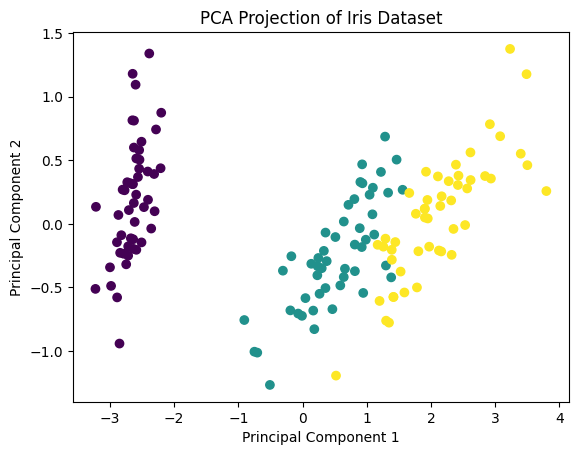

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(x)

plt.scatter(X_pca[:, 0], X_pca[:, 1],c=y)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Projection of Iris Dataset")
plt.show()

In [ ]:
print(pca.explained_variance_ratio_)
print(sum(pca.explained_variance_ratio_))

[0.92461872 0.05306648]
0.9776852063187963


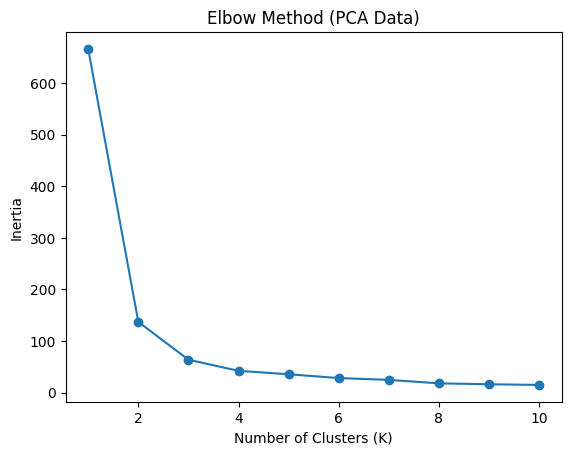

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia_values = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42)
    kmeans.fit(X_pca)
    inertia_values.append(kmeans.inertia_)

plt.plot(range(1, 11), inertia_values, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method (PCA Data)")
plt.show()

# 3 is the elbow point 

In [ ]:
kmeans = KMeans(n_clusters=3, init='k-means++', random_state=42)
kmeans.fit(X_pca)

labels = kmeans.labels_
print(labels)
#all the samples are clustered

[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 0 2 0 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 0 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 0 2 0 0 0 0 2 0 0 0 0
 0 0 2 2 0 0 0 0 2 0 2 0 2 0 0 2 2 0 0 0 0 0 2 0 0 0 0 2 0 0 0 2 0 0 0 2 0
 0 2]


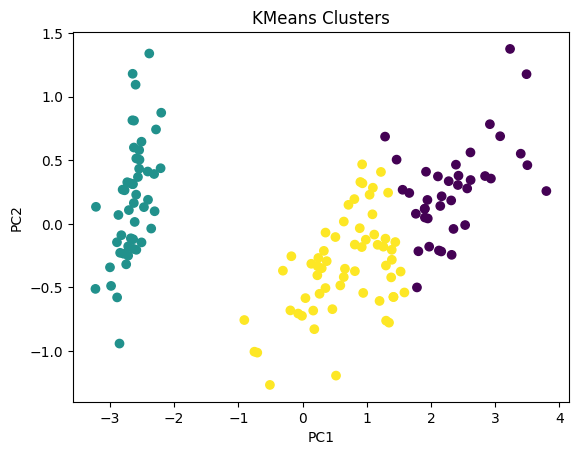

In [ ]:
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("KMeans Clusters")
plt.show()

In [ ]:
print("Inertia:", kmeans.inertia_)
from sklearn.metrics import silhouette_score

score = silhouette_score(X_pca, labels)
print("Silhouette Score:", score)

Inertia: 63.81994202200121
Silhouette Score: 0.5976764219547992


In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

kmeans_full = KMeans(n_clusters=3, init='k-means++', random_state=42)
labels_full = kmeans_full.fit_predict(x_scaled)

print("Inertia (4D):", kmeans_full.inertia_)
print("Silhouette (4D):", silhouette_score(x_scaled, labels_full))

Inertia (4D): 191.0247368531796
Silhouette (4D): 0.4798814508199818
